## QTMPandas key features

You can try out vgridpandas by using the cloud-computing platforms below without having to install anything on your computer:

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgridpandas/blob/main/docs/notebooks/10_qtm.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgridpandas/HEAD?filepath=docs/notebooks/10_qtm.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgridpandas/blob/main/docs/notebooks/10_qtm.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgridpandas/10_qtm.ipynb)

Full VgridPandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid in Python or CLI, use [vgrid](https://pypi.org/project/vgrid/) package. Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgridpandas
Uncomment the following line to install [vgridpandas](https://pypi.org/project/vgridpandas/).

In [ ]:
# %pip install vgridpandas

### Import qtmpandas

In [12]:
from vgridpandas import qtmpandas

### Latlon to QTM

#### Pandas

In [3]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv')
resolution = 9
df = df.qtm.latlon2qtm(resolution, lat_col='lat', lon_col='lon')
df

,lon,lat,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,qtm,qtm_res
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,103213101,9
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,103213101,9
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,103213101,9
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,103213101,9
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,103213101,9
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,103203323,9
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,103203323,9
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,103203323,9
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,103203323,9


#### GeoPandas

In [5]:
import geopandas as gpd

df = gpd.read_file('https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/housing.geojson')
resolution = 9
df = df.qtm.latlon2qtm(resolution)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,geometry,qtm,qtm_res
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,POINT (-122.23 37.88),103213101,9
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,POINT (-122.22 37.86),103213101,9
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,POINT (-122.24 37.85),103213101,9
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,POINT (-122.25 37.85),103213101,9
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,POINT (-122.25 37.85),103213101,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,POINT (-121.09 39.48),103203323,9
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,POINT (-121.21 39.49),103203323,9
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,POINT (-121.22 39.43),103203323,9
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,POINT (-121.32 39.43),103203323,9


### QTM to geo

<Axes: >

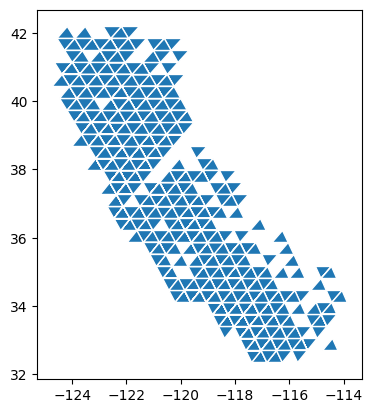

In [6]:
df = df.qtm.qtm2geo(qtm_col='qtm')
df.plot(edgecolor='white')

### (Multi)Polygon to QTM

<Axes: >

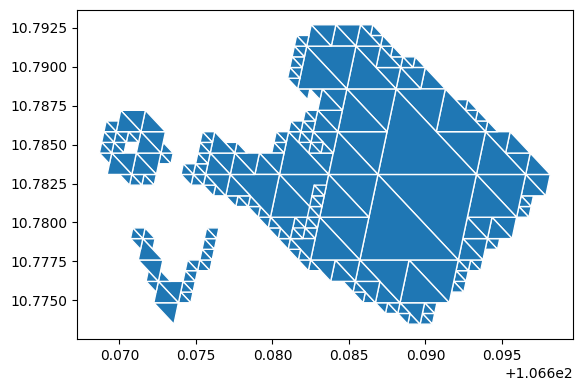

In [7]:
import geopandas as gpd

gdf = gpd.read_file('https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon.geojson')
resolution = 18
gdf_polyfill = gdf.qtm.polyfill(resolution, compact=True, predicate='intersect', explode=False)
gdf_polyfill = gdf_polyfill.qtm.qtm2geo(qtm_col='qtm')
gdf_polyfill.plot(edgecolor='white')

### QTM binning

#### Pandas

<Axes: >

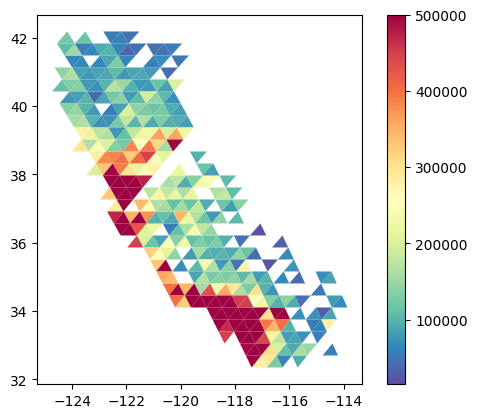

In [13]:
import pandas as pd

resolution = 9
df = pd.read_csv('https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv')
stats = 'max'
numeric_col = 'median_house_value'
df_bin = df.qtm.qtmbin(resolution=resolution,
                    stats=stats,
                    numeric_col=numeric_col,
                    # category_col='ocean_proximity',
                    )
df_bin.plot(
    column=f'{numeric_col}_{stats}',
    cmap='Spectral_r',
    legend=True,
    linewidth=0.2,
)

#### GeoPandas

<Axes: >

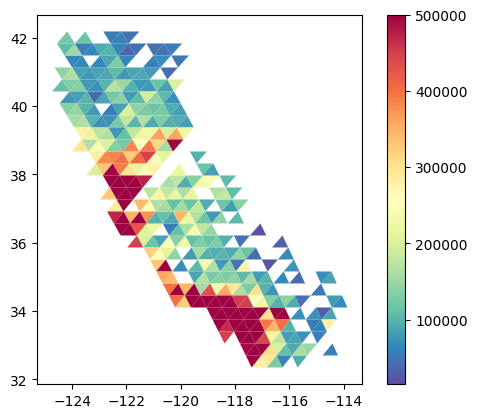

In [16]:
import geopandas as gpd

resolution = 9
df = gpd.read_file('https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/housing.geojson')
stats = 'max'
numeric_col = 'median_house_value'
df_bin = df.qtm.qtmbin(resolution=resolution,
                    stats=stats,
                    numeric_col=numeric_col,
                    # category_col='ocean_proximity',
                    )
df_bin.plot(
    column=f'{numeric_col}_{stats}',
    cmap='Spectral_r',
    legend=True,
    linewidth=0.2,
)